In [1]:
%pip install --quiet seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

In [3]:
df = pd.read_csv('airbnb_processed_data_multimodal.csv')

# Drop text_quality_percentile — computed on full dataset so encodes leakage
# It is excluded from all modelling; retained here only for EDA context
if 'text_quality_percentile' in df.columns:
    df_eda = df.drop(columns=['text_quality_percentile'])
else:
    df_eda = df.copy()

print(f"Dataset shape: {df_eda.shape[0]:,} listings × {df_eda.shape[1]:,} features")
print(f"\nFeature groups:")

bert_name = [c for c in df_eda.columns if c.startswith('name_bert_')]
bert_desc = [c for c in df_eda.columns if c.startswith('desc_bert_')]
resnet    = [c for c in df_eda.columns if c.startswith('img_resnet_')]
has_pic   = [c for c in df_eda.columns if c == 'has_picture']
has_cols  = [c for c in df_eda.columns if c.startswith('has_') and c != 'has_picture']
structured = [c for c in df_eda.columns
              if not c.startswith(('name_bert_', 'desc_bert_', 'img_resnet_',
                                   'has_', 'room_type_', 'property_type_',
                                   'text_quality_category_'))
              and c not in ['price', 'has_picture']]

print(f"  Structured features:       {len(structured)}")
print(f"  Amenity binary features:   {len(has_cols)}")
print(f"  DistilBERT name features:  {len(bert_name)}")
print(f"  DistilBERT desc features:  {len(bert_desc)}")
print(f"  ResNet50 image features:   {len(resnet)}")
print(f"  has_picture:               {len(has_pic)}")

print(f"\nMissing values: {df_eda.isnull().sum().sum()} total")
print(f"Price range: £{df_eda['price'].min():.0f} — £{df_eda['price'].max():.0f}")

Dataset shape: 6,562 listings × 291 features

Feature groups:
  Structured features:       78
  Amenity binary features:   89
  DistilBERT name features:  32
  DistilBERT desc features:  32
  ResNet50 image features:   32
  has_picture:               1

Missing values: 0 total
Price range: £22 — £1012


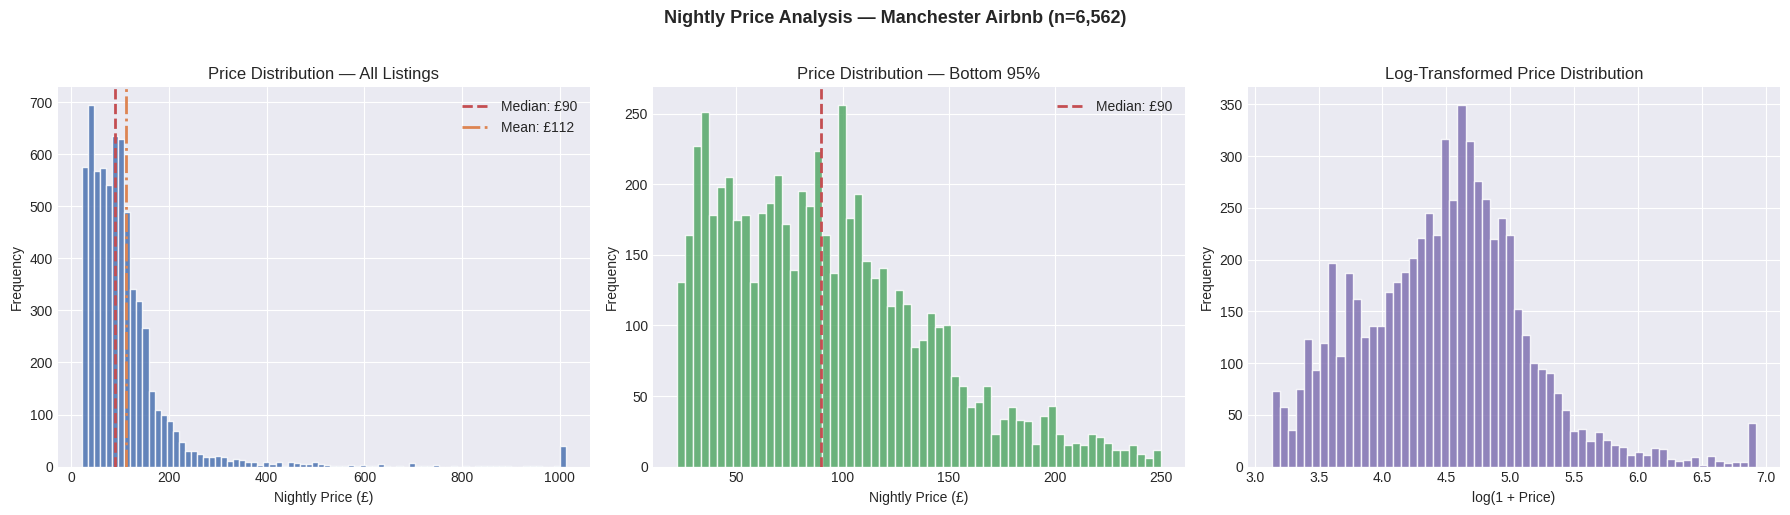

Price Statistics:
count   6562.000
mean     112.005
std      112.318
min       22.000
25%       55.000
50%       90.000
75%      129.000
max     1012.095

Skewness:  4.86
Kurtosis:  31.33

Percentiles:
  10th: £36
  25th: £55
  50th: £90
  75th: £129
  90th: £185
  95th: £251
  99th: £698


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Full distribution
axes[0].hist(df_eda['price'], bins=80, color='#4C72B0', edgecolor='white',
             alpha=0.85)
axes[0].axvline(df_eda['price'].median(), color='#C44E52', linewidth=2,
                linestyle='--', label=f'Median: £{df_eda["price"].median():.0f}')
axes[0].axvline(df_eda['price'].mean(), color='#DD8452', linewidth=2,
                linestyle='-.',  label=f'Mean: £{df_eda["price"].mean():.0f}')
axes[0].set_xlabel('Nightly Price (£)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price Distribution — All Listings')
axes[0].legend()

# Bottom 95% to handle extreme values
p95 = df_eda['price'].quantile(0.95)
axes[1].hist(df_eda[df_eda['price'] <= p95]['price'], bins=60,
             color='#55A868', edgecolor='white', alpha=0.85)
axes[1].axvline(df_eda['price'].median(), color='#C44E52', linewidth=2,
                linestyle='--', label=f'Median: £{df_eda["price"].median():.0f}')
axes[1].set_xlabel('Nightly Price (£)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Price Distribution — Bottom 95%')
axes[1].legend()

# Log-scale to reveal shape
axes[2].hist(np.log1p(df_eda['price']), bins=60, color='#8172B2',
             edgecolor='white', alpha=0.85)
axes[2].set_xlabel('log(1 + Price)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Log-Transformed Price Distribution')

plt.suptitle('Nightly Price Analysis — Manchester Airbnb (n=6,562)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Price Statistics:")
print(df_eda['price'].describe().to_string())
print(f"\nSkewness:  {df_eda['price'].skew():.2f}")
print(f"Kurtosis:  {df_eda['price'].kurtosis():.2f}")
print(f"\nPercentiles:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  {p}th: £{df_eda['price'].quantile(p/100):.0f}")

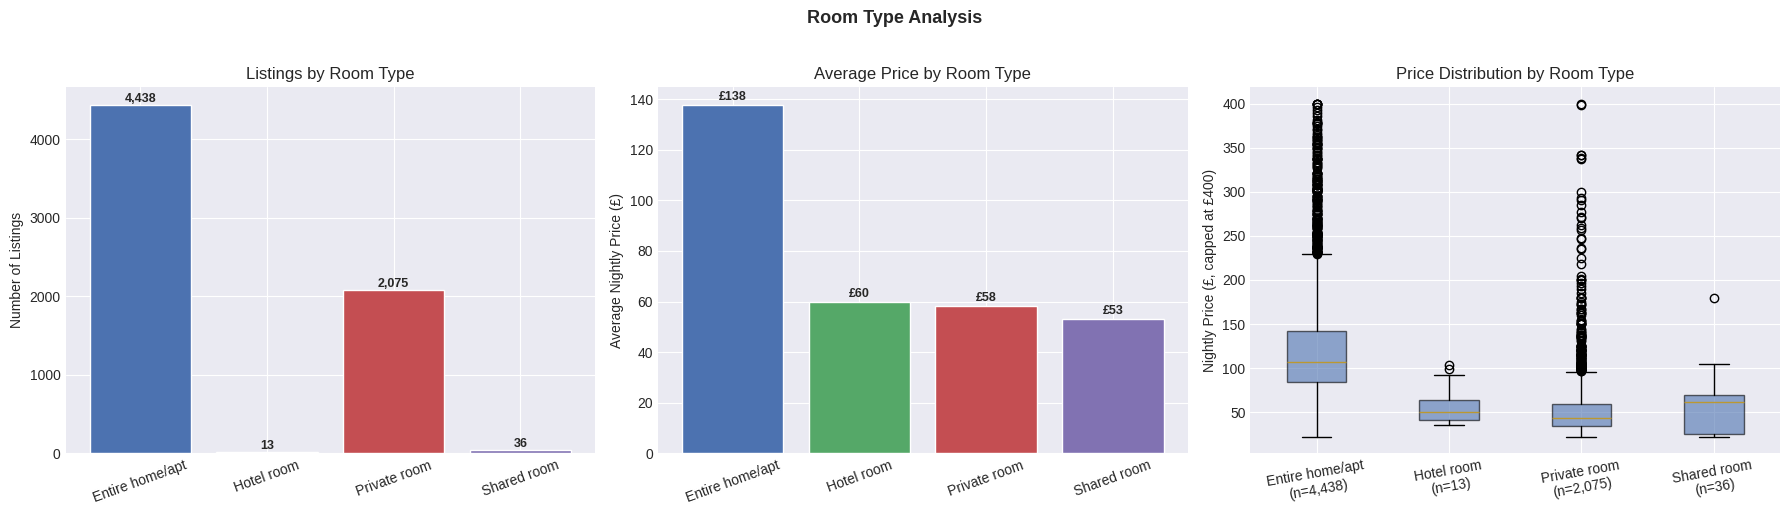

In [5]:
room_cols = [c for c in df_eda.columns if c.startswith('room_type_')]
room_labels = [c.replace('room_type_', '') for c in room_cols]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Count by room type
room_counts = df_eda[room_cols].sum()
room_counts.index = room_labels
axes[0].bar(room_counts.index, room_counts.values,
            color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'],
            edgecolor='white')
axes[0].set_ylabel('Number of Listings')
axes[0].set_title('Listings by Room Type')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(room_counts.values):
    axes[0].text(i, v + 40, f'{v:,}', ha='center', fontweight='bold', fontsize=9)

# Average price by room type
avg_price_room = {}
for col, label in zip(room_cols, room_labels):
    avg_price_room[label] = df_eda[df_eda[col] == 1]['price'].mean()

axes[1].bar(avg_price_room.keys(), avg_price_room.values(),
            color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'],
            edgecolor='white')
axes[1].set_ylabel('Average Nightly Price (£)')
axes[1].set_title('Average Price by Room Type')
axes[1].tick_params(axis='x', rotation=20)
for i, (k, v) in enumerate(avg_price_room.items()):
    axes[1].text(i, v + 2, f'£{v:.0f}', ha='center', fontweight='bold', fontsize=9)

# Box plot of prices by room type (capped at £400 for readability)
plot_data = []
plot_labels = []
for col, label in zip(room_cols, room_labels):
    data = df_eda[df_eda[col] == 1]['price']
    if len(data) > 5:
        plot_data.append(data[data <= 400].values)
        plot_labels.append(f'{label}\n(n={len(data):,})')

axes[2].boxplot(plot_data, labels=plot_labels, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.6))
axes[2].set_ylabel('Nightly Price (£, capped at £400)')
axes[2].set_title('Price Distribution by Room Type')
axes[2].tick_params(axis='x', rotation=10)

plt.suptitle('Room Type Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_room_type.png', dpi=150, bbox_inches='tight')
plt.show()

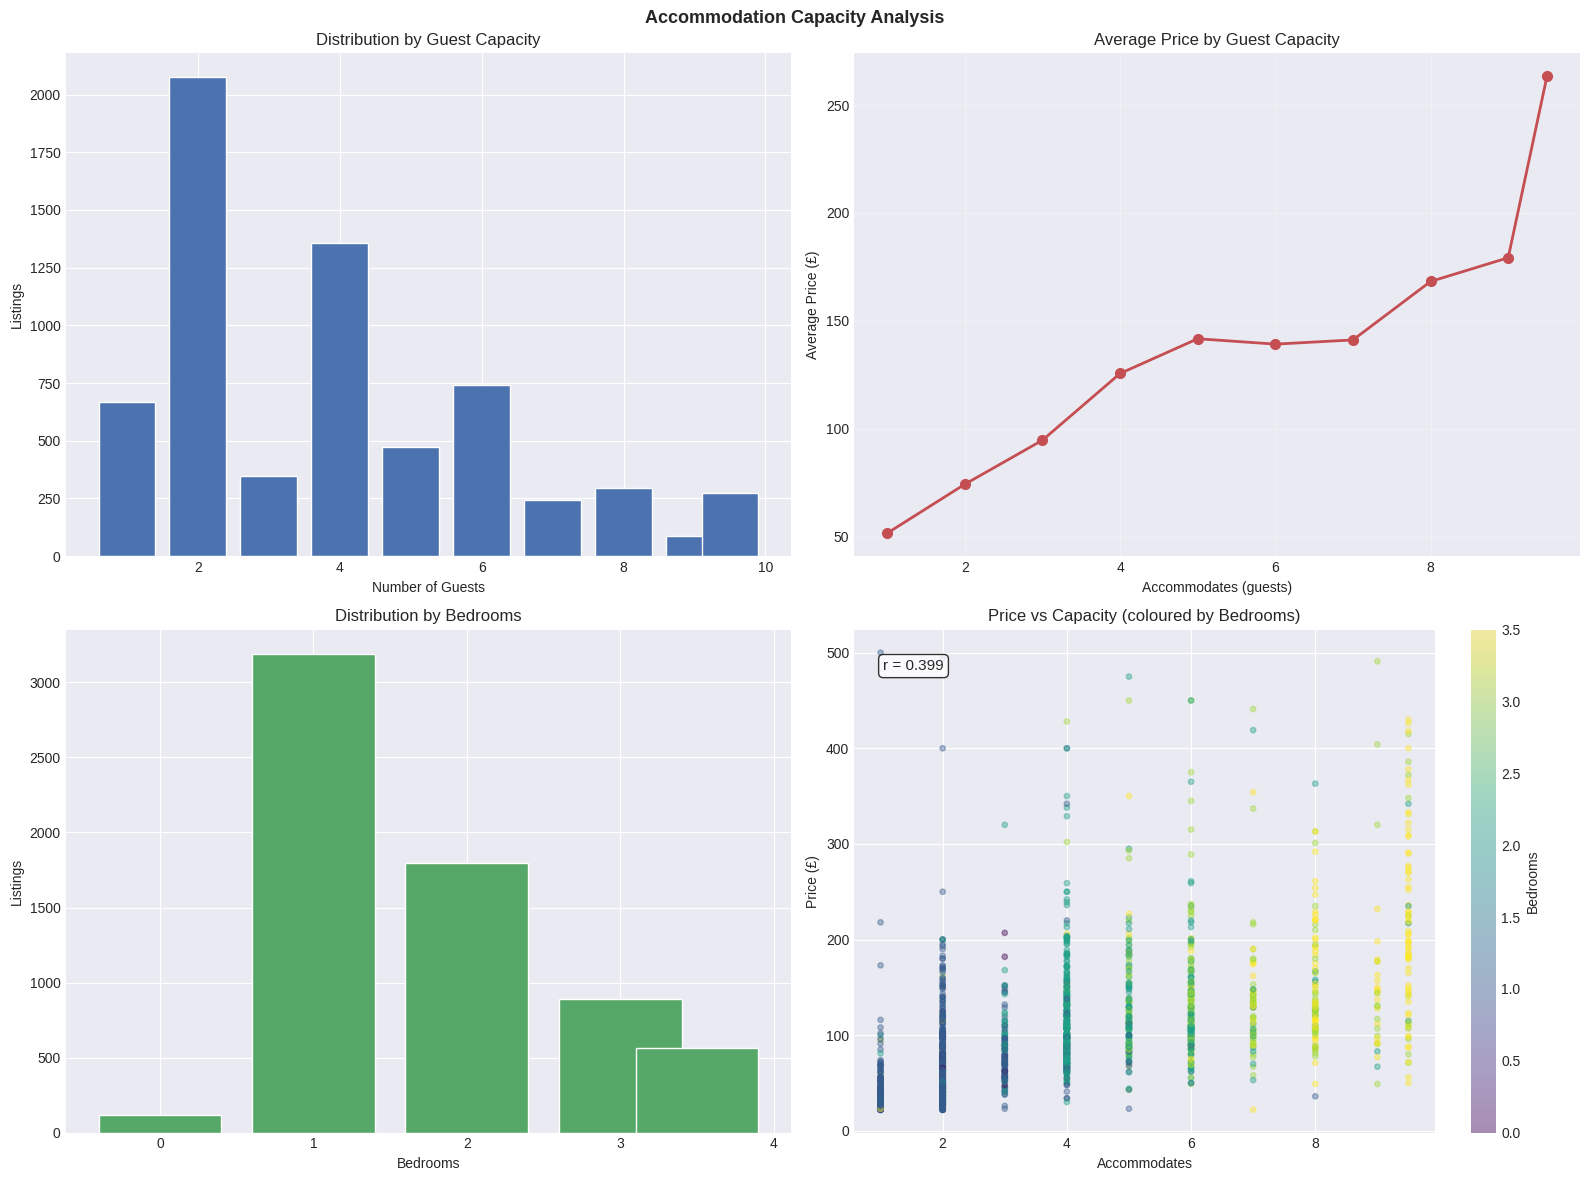

Capacity Statistics:
       accommodates  bedrooms     beds  bathrooms
count      6562.000  6562.000 6562.000   6562.000
mean          3.899     1.744    2.296      1.343
std           2.327     0.906    1.539      0.495
min           1.000     0.000    0.000      0.250
25%           2.000     1.000    1.000      1.000
50%           4.000     1.000    2.000      1.000
75%           6.000     2.000    3.000      2.000
max           9.500     3.500    6.000      2.250


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Accommodates distribution
accom_counts = df_eda['accommodates'].value_counts().sort_index()
axes[0, 0].bar(accom_counts.index, accom_counts.values,
               color='#4C72B0', edgecolor='white')
axes[0, 0].set_xlabel('Number of Guests')
axes[0, 0].set_ylabel('Listings')
axes[0, 0].set_title('Distribution by Guest Capacity')

# Average price by accommodates
avg_price_accom = df_eda.groupby('accommodates')['price'].mean()
axes[0, 1].plot(avg_price_accom.index, avg_price_accom.values,
                marker='o', linewidth=2, markersize=7, color='#C44E52')
axes[0, 1].set_xlabel('Accommodates (guests)')
axes[0, 1].set_ylabel('Average Price (£)')
axes[0, 1].set_title('Average Price by Guest Capacity')
axes[0, 1].grid(True, alpha=0.3)

# Bedrooms distribution
bed_counts = df_eda['bedrooms'].value_counts().sort_index()
axes[1, 0].bar(bed_counts.index, bed_counts.values,
               color='#55A868', edgecolor='white')
axes[1, 0].set_xlabel('Bedrooms')
axes[1, 0].set_ylabel('Listings')
axes[1, 0].set_title('Distribution by Bedrooms')

# Price vs accommodates scatter
sample = df_eda[df_eda['price'] <= 500].sample(min(2000, len(df_eda)), random_state=42)
sc = axes[1, 1].scatter(sample['accommodates'], sample['price'],
                         c=sample['bedrooms'], cmap='viridis', alpha=0.4, s=15)
plt.colorbar(sc, ax=axes[1, 1], label='Bedrooms')
axes[1, 1].set_xlabel('Accommodates')
axes[1, 1].set_ylabel('Price (£)')
axes[1, 1].set_title('Price vs Capacity (coloured by Bedrooms)')

# Correlation annotation
r, _ = pearsonr(df_eda['accommodates'], df_eda['price'])
axes[1, 1].annotate(f'r = {r:.3f}', xy=(0.05, 0.92),
                    xycoords='axes fraction', fontsize=11,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Accommodation Capacity Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_capacity.png', dpi=150, bbox_inches='tight')
plt.show()

print("Capacity Statistics:")
print(df_eda[['accommodates', 'bedrooms', 'beds', 'bathrooms']].describe().to_string())

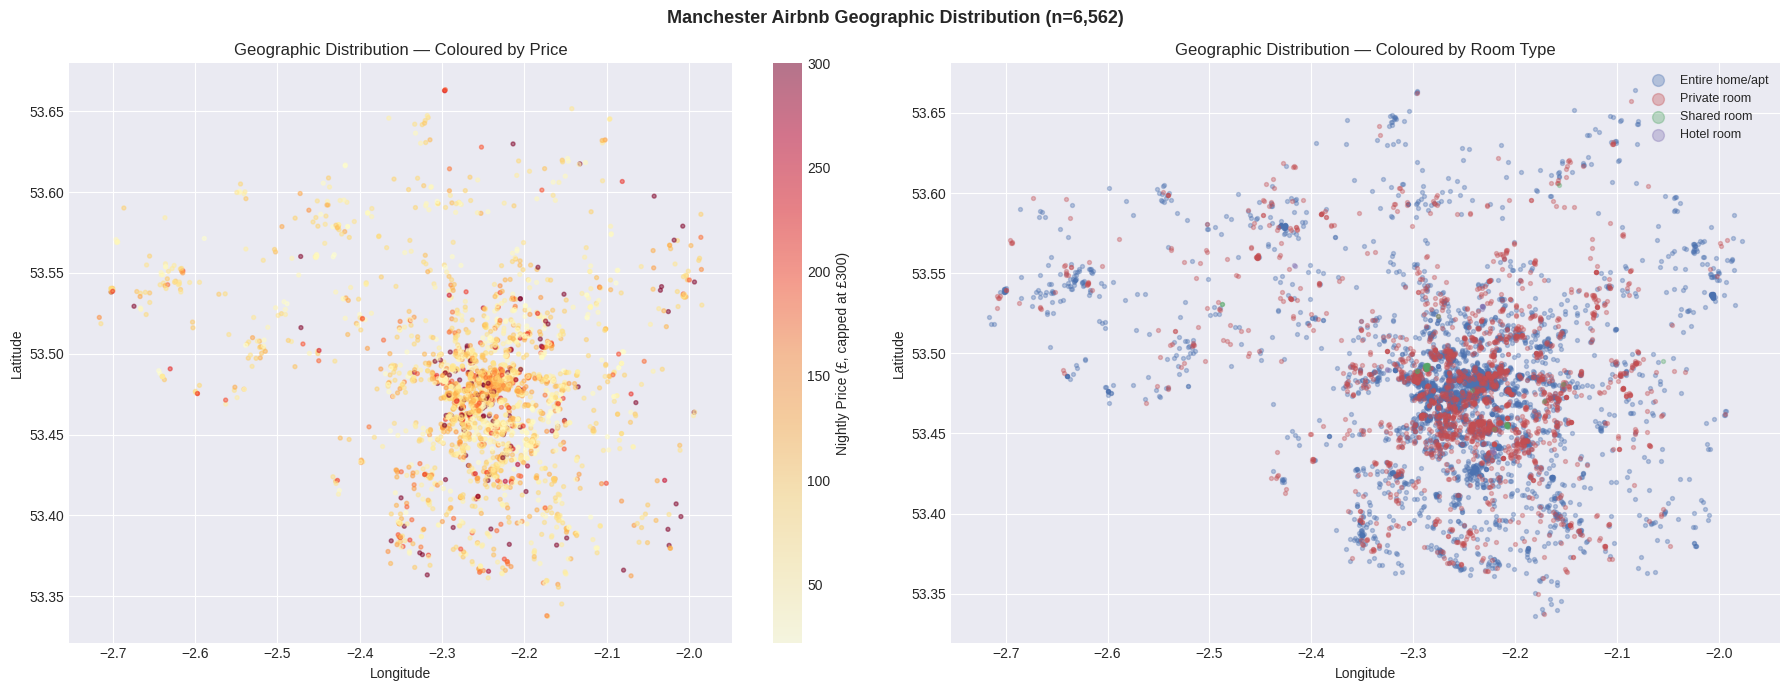


Price by Approximate Area:
                          count    mean  median
area_proxy                                     
North Greater Manchester   3281 110.831  91.000
South Greater Manchester   3281 113.179  89.000


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter coloured by price
sample_geo = df_eda.sample(min(3000, len(df_eda)), random_state=42)
sc1 = axes[0].scatter(sample_geo['longitude'], sample_geo['latitude'],
                       c=np.clip(sample_geo['price'], 0, 300),
                       cmap='YlOrRd', alpha=0.5, s=8)
plt.colorbar(sc1, ax=axes[0], label='Nightly Price (£, capped at £300)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('Geographic Distribution — Coloured by Price')

# Scatter coloured by room type
room_color_map = {
    'room_type_Entire home/apt': '#4C72B0',
    'room_type_Private room':    '#C44E52',
    'room_type_Shared room':     '#55A868',
    'room_type_Hotel room':      '#8172B2'
}
handles = []
for col, color in room_color_map.items():
    mask = df_eda[col] == 1
    label = col.replace('room_type_', '')
    axes[1].scatter(df_eda.loc[mask, 'longitude'],
                    df_eda.loc[mask, 'latitude'],
                    c=color, alpha=0.35, s=8, label=label)

axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('Geographic Distribution — Coloured by Room Type')
axes[1].legend(markerscale=3, fontsize=9)

plt.suptitle('Manchester Airbnb Geographic Distribution (n=6,562)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_geographic.png', dpi=150, bbox_inches='tight')
plt.show()

# Price by geographic area (latitude bands as proxy for north/south)
lat_median = df_eda['latitude'].median()
df_eda['area_proxy'] = np.where(df_eda['latitude'] > lat_median,
                                 'North Greater Manchester',
                                 'South Greater Manchester')
area_stats = df_eda.groupby('area_proxy')['price'].agg(['count', 'mean', 'median'])
print("\nPrice by Approximate Area:")
print(area_stats.to_string())

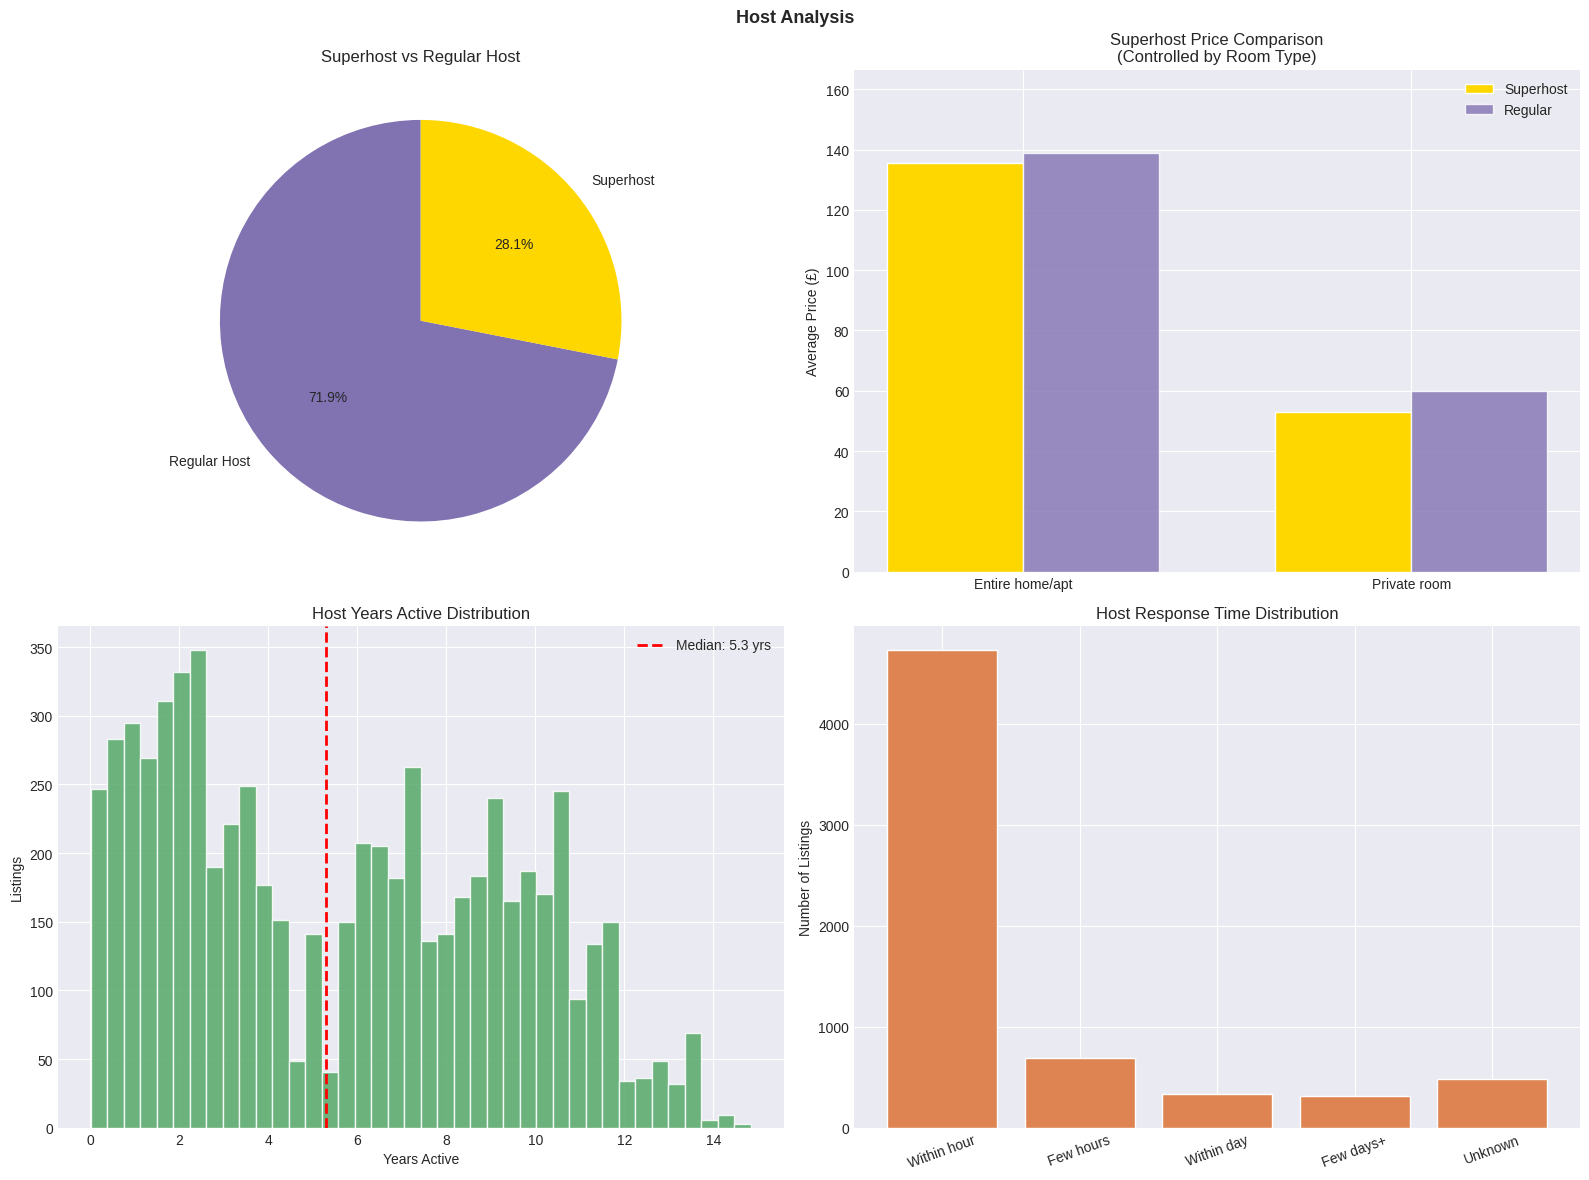

Overall superhost premium: -1.8%
  (Superhost: £110.52  |  Regular: £112.59)

Controlled for room type:
  Entire home — Superhost: £135.56  Regular: £138.74  (-2.3%)
  Private room — Superhost: £52.85  Regular: £60.07  (-12.0%)

Note: The marginal overall premium reflects a composition effect — superhosts hold a higher proportion of private rooms, which are inherently cheaper than entire properties.


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Superhost distribution
superhost_counts = df_eda['host_is_superhost'].value_counts()
labels_sh = ['Regular Host', 'Superhost']
colors_sh  = ['#8172B2', '#FFD700']
axes[0, 0].pie([superhost_counts.get(0, 0), superhost_counts.get(1, 0)],
               labels=labels_sh, autopct='%1.1f%%',
               colors=colors_sh, startangle=90)
axes[0, 0].set_title('Superhost vs Regular Host')

# Superhost price comparison — within room types to control for confounding
superhost_entire = df_eda[(df_eda['host_is_superhost'] == 1) &
                           (df_eda['room_type_Entire home/apt'] == 1)]['price'].mean()
regular_entire   = df_eda[(df_eda['host_is_superhost'] == 0) &
                           (df_eda['room_type_Entire home/apt'] == 1)]['price'].mean()
superhost_private = df_eda[(df_eda['host_is_superhost'] == 1) &
                            (df_eda['room_type_Private room'] == 1)]['price'].mean()
regular_private   = df_eda[(df_eda['host_is_superhost'] == 0) &
                            (df_eda['room_type_Private room'] == 1)]['price'].mean()

x = np.arange(2)
w = 0.35
axes[0, 1].bar(x - w/2, [superhost_entire, superhost_private],
               w, label='Superhost', color='#FFD700', edgecolor='white')
axes[0, 1].bar(x + w/2, [regular_entire, regular_private],
               w, label='Regular', color='#8172B2', edgecolor='white', alpha=0.8)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(['Entire home/apt', 'Private room'])
axes[0, 1].set_ylabel('Average Price (£)')
axes[0, 1].set_title('Superhost Price Comparison\n(Controlled by Room Type)')
axes[0, 1].legend()
axes[0, 1].set_ylim(0, max(superhost_entire, regular_entire) * 1.2)

# Host years active
axes[1, 0].hist(df_eda['host_years_active'].dropna(), bins=40,
                color='#55A868', edgecolor='white', alpha=0.85)
axes[1, 0].axvline(df_eda['host_years_active'].median(), color='red',
                    linestyle='--', linewidth=2,
                    label=f'Median: {df_eda["host_years_active"].median():.1f} yrs')
axes[1, 0].set_xlabel('Years Active')
axes[1, 0].set_ylabel('Listings')
axes[1, 0].set_title('Host Years Active Distribution')
axes[1, 0].legend()

# Response time distribution
rt_map = {0: 'Within hour', 1: 'Few hours', 2: 'Within day',
          3: 'Few days+', 4: 'Unknown'}
rt_counts = df_eda['host_response_time_encoded'].value_counts().sort_index()
rt_labels  = [rt_map.get(i, str(i)) for i in rt_counts.index]
axes[1, 1].bar(rt_labels, rt_counts.values, color='#DD8452', edgecolor='white')
axes[1, 1].set_ylabel('Number of Listings')
axes[1, 1].set_title('Host Response Time Distribution')
axes[1, 1].tick_params(axis='x', rotation=20)

plt.suptitle('Host Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_host.png', dpi=150, bbox_inches='tight')
plt.show()

# Note on superhost price premium
overall_super = df_eda[df_eda['host_is_superhost'] == 1]['price'].mean()
overall_reg   = df_eda[df_eda['host_is_superhost'] == 0]['price'].mean()
premium_overall = ((overall_super - overall_reg) / overall_reg) * 100

print(f"Overall superhost premium: {premium_overall:.1f}%")
print(f"  (Superhost: £{overall_super:.2f}  |  Regular: £{overall_reg:.2f})")
print(f"\nControlled for room type:")
print(f"  Entire home — Superhost: £{superhost_entire:.2f}  Regular: £{regular_entire:.2f}  "
      f"({((superhost_entire-regular_entire)/regular_entire)*100:+.1f}%)")
print(f"  Private room — Superhost: £{superhost_private:.2f}  Regular: £{regular_private:.2f}  "
      f"({((superhost_private-regular_private)/regular_private)*100:+.1f}%)")
print(f"\nNote: The marginal overall premium reflects a composition effect — "
      f"superhosts hold a higher proportion of private rooms, which are "
      f"inherently cheaper than entire properties.")

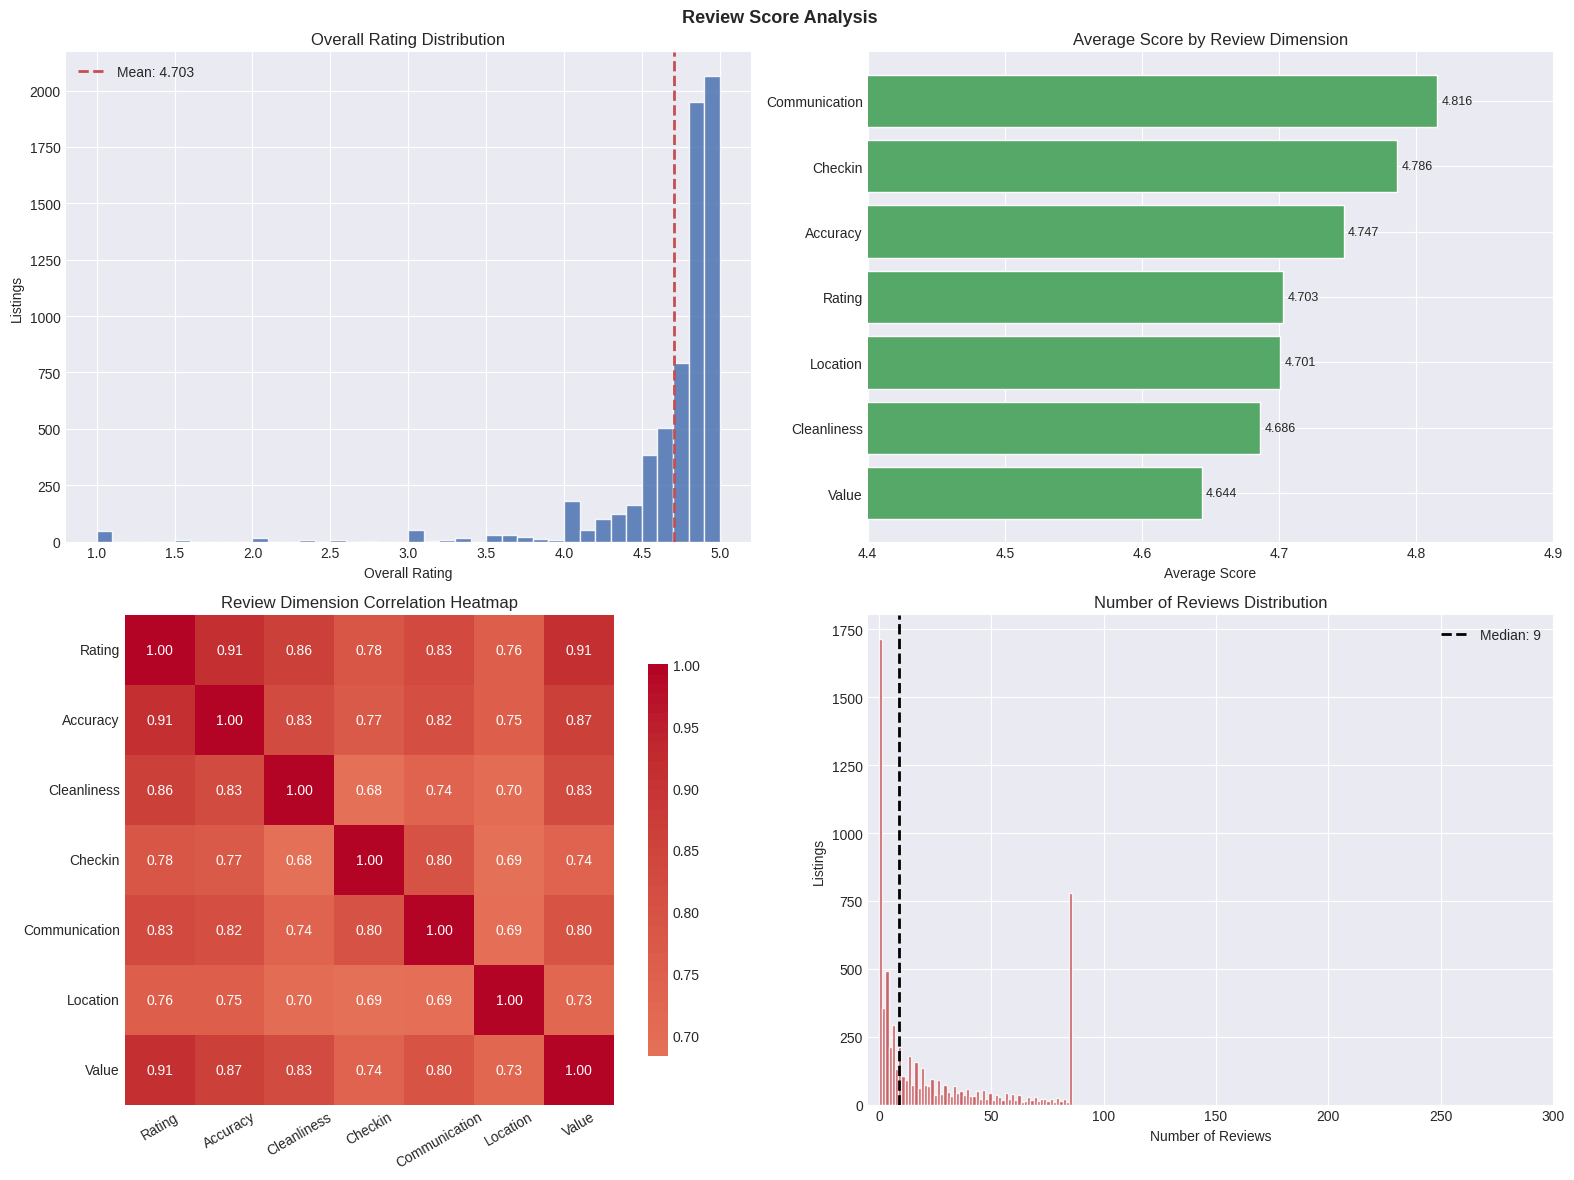

Review Score Statistics:
       review_scores_rating  review_scores_accuracy  review_scores_cleanliness  review_scores_checkin  review_scores_communication  review_scores_location  review_scores_value
count              6562.000                6562.000                   6562.000               6562.000                     6562.000                6562.000             6562.000
mean                  4.703                   4.747                      4.686                  4.786                        4.816                   4.701                4.644
std                   0.481                   0.462                      0.480                  0.456                        0.430                   0.403                0.490
min                   1.000                   1.000                      1.000                  1.000                        1.000                   1.000                1.000
25%                   4.670                   4.740                      4.650                 

In [9]:
review_cols = ['review_scores_rating', 'review_scores_accuracy',
               'review_scores_cleanliness', 'review_scores_checkin',
               'review_scores_communication', 'review_scores_location',
               'review_scores_value']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribution of overall rating
axes[0, 0].hist(df_eda['review_scores_rating'].dropna(), bins=40,
                color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0, 0].axvline(df_eda['review_scores_rating'].mean(), color='#C44E52',
                    linewidth=2, linestyle='--',
                    label=f'Mean: {df_eda["review_scores_rating"].mean():.3f}')
axes[0, 0].set_xlabel('Overall Rating')
axes[0, 0].set_ylabel('Listings')
axes[0, 0].set_title('Overall Rating Distribution')
axes[0, 0].legend()

# Average scores by dimension
review_means = df_eda[review_cols].mean().sort_values(ascending=True)
clean_labels  = [c.replace('review_scores_', '').title() for c in review_means.index]
axes[0, 1].barh(clean_labels, review_means.values, color='#55A868', edgecolor='white')
axes[0, 1].set_xlabel('Average Score')
axes[0, 1].set_title('Average Score by Review Dimension')
axes[0, 1].set_xlim([4.4, 4.9])
for i, v in enumerate(review_means.values):
    axes[0, 1].text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)

# Correlation heatmap of review dimensions
review_corr = df_eda[review_cols].corr()
clean_labels2 = [c.replace('review_scores_', '').title() for c in review_cols]
sns.heatmap(review_corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[1, 0],
            xticklabels=clean_labels2, yticklabels=clean_labels2,
            cbar_kws={'shrink': 0.8})
axes[1, 0].set_title('Review Dimension Correlation Heatmap')
axes[1, 0].tick_params(axis='x', rotation=30)

# Number of reviews distribution
axes[1, 1].hist(df_eda['number_of_reviews'], bins=60,
                color='#C44E52', edgecolor='white', alpha=0.85)
axes[1, 1].axvline(df_eda['number_of_reviews'].median(), color='black',
                    linewidth=2, linestyle='--',
                    label=f'Median: {df_eda["number_of_reviews"].median():.0f}')
axes[1, 1].set_xlabel('Number of Reviews')
axes[1, 1].set_ylabel('Listings')
axes[1, 1].set_title('Number of Reviews Distribution')
axes[1, 1].set_xlim([-5, 300])
axes[1, 1].legend()

plt.suptitle('Review Score Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_reviews.png', dpi=150, bbox_inches='tight')
plt.show()

print("Review Score Statistics:")
print(df_eda[review_cols].describe().to_string())

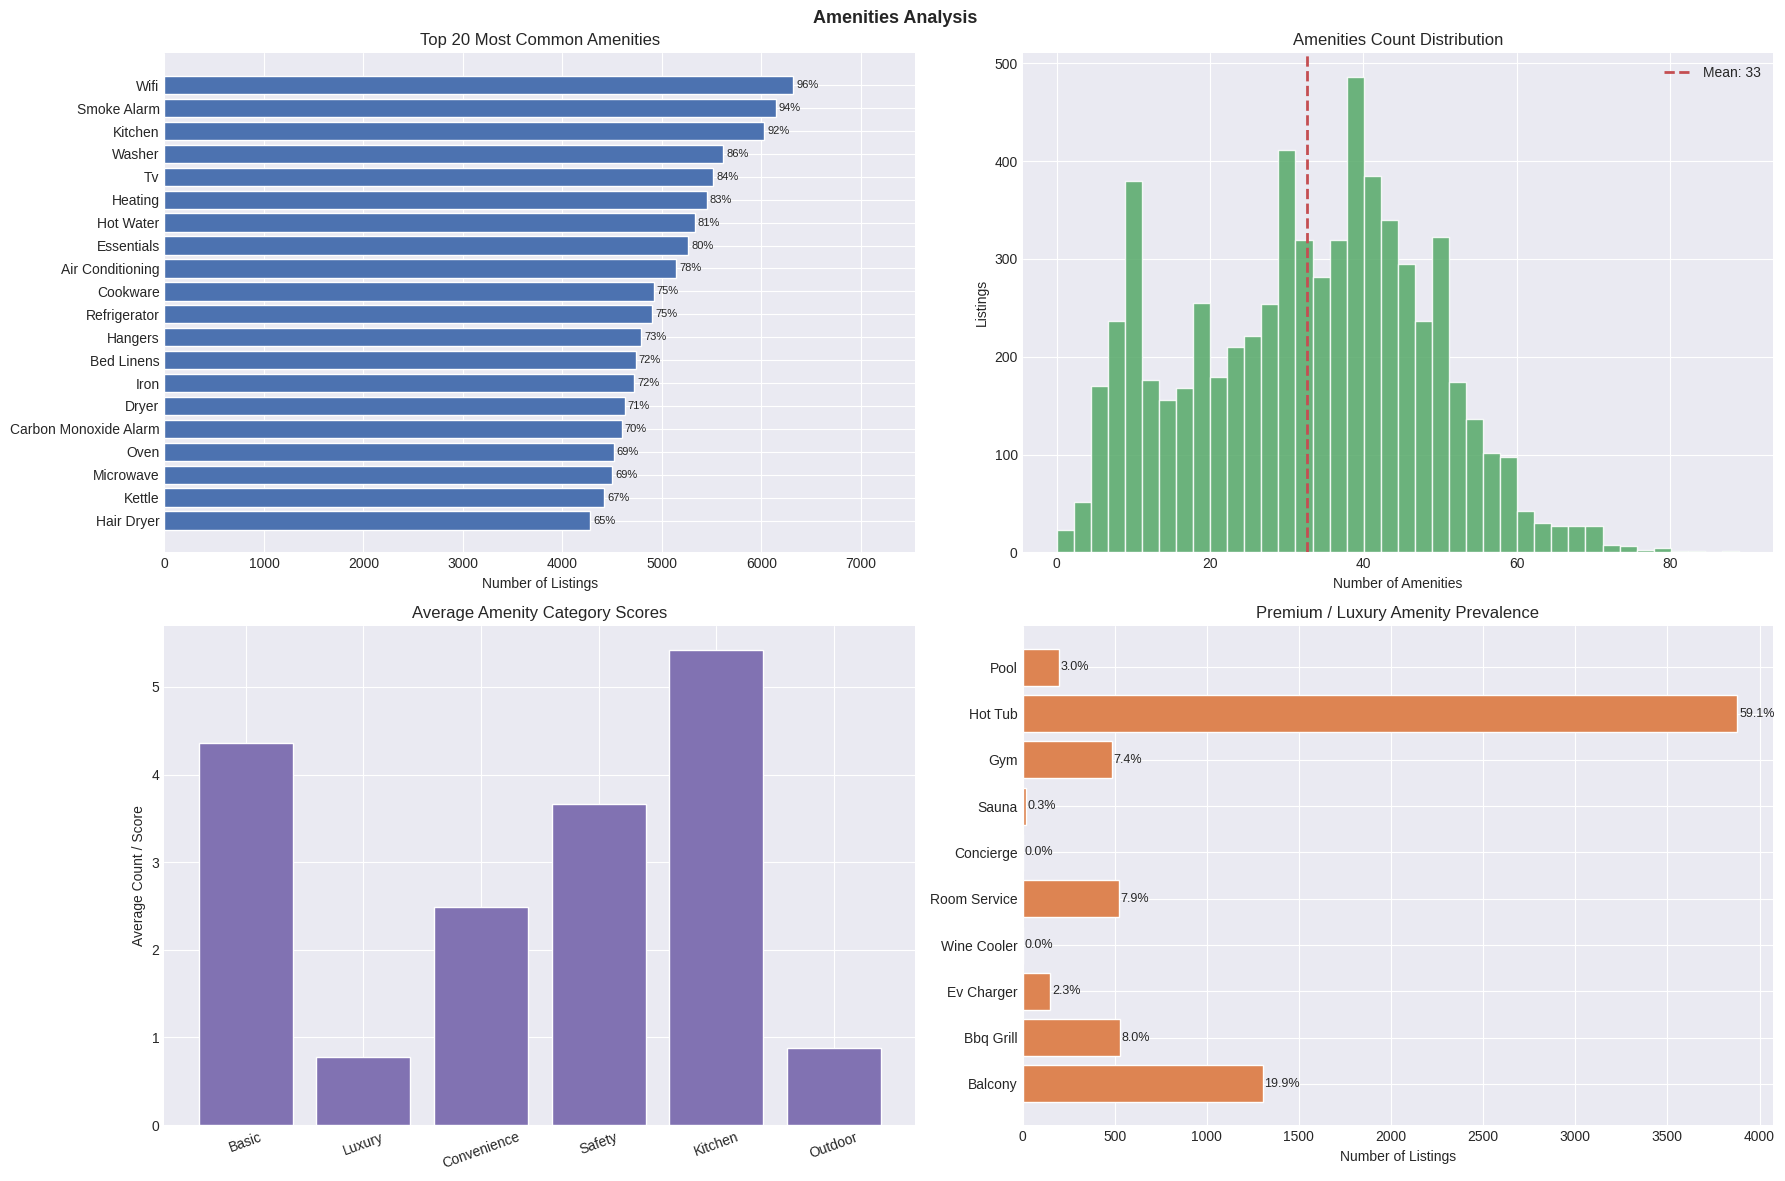


Top 15 Most Common Amenities:
  Wifi                          : 6,324 (96.4%)
  Smoke Alarm                   : 6,148 (93.7%)
  Kitchen                       : 6,031 (91.9%)
  Washer                        : 5,620 (85.6%)
  Tv                            : 5,515 (84.0%)
  Heating                       : 5,450 (83.1%)
  Hot Water                     : 5,329 (81.2%)
  Essentials                    : 5,266 (80.2%)
  Air Conditioning              : 5,143 (78.4%)
  Cookware                      : 4,920 (75.0%)
  Refrigerator                  : 4,906 (74.8%)
  Hangers                       : 4,795 (73.1%)
  Bed Linens                    : 4,736 (72.2%)
  Iron                          : 4,723 (72.0%)
  Dryer                         : 4,628 (70.5%)


In [10]:
has_cols_only = [c for c in df_eda.columns
                 if c.startswith('has_') and c != 'has_picture']
amenity_prevalence = df_eda[has_cols_only].sum().sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top 20 amenities by prevalence
top20 = amenity_prevalence.head(20)
clean_names = [c.replace('has_', '').replace('_', ' ').title() for c in top20.index]
axes[0, 0].barh(clean_names[::-1], top20.values[::-1],
                color='#4C72B0', edgecolor='white')
axes[0, 0].set_xlabel('Number of Listings')
axes[0, 0].set_title('Top 20 Most Common Amenities')
axes[0, 0].set_xlim([0, len(df_eda) * 1.15])
for i, v in enumerate(top20.values[::-1]):
    pct = v / len(df_eda) * 100
    axes[0, 0].text(v + 30, i, f'{pct:.0f}%', va='center', fontsize=8)

# Amenities count distribution
axes[0, 1].hist(df_eda['amenities_count'], bins=40,
                color='#55A868', edgecolor='white', alpha=0.85)
axes[0, 1].axvline(df_eda['amenities_count'].mean(), color='#C44E52',
                    linewidth=2, linestyle='--',
                    label=f'Mean: {df_eda["amenities_count"].mean():.0f}')
axes[0, 1].set_xlabel('Number of Amenities')
axes[0, 1].set_ylabel('Listings')
axes[0, 1].set_title('Amenities Count Distribution')
axes[0, 1].legend()

# Average price by amenity category score
category_score_cols = {
    'Basic':        'basic_amenities_score',
    'Luxury':       'luxury_amenities_score',
    'Convenience':  'convenience_amenities_score',
    'Safety':       'safety_amenities_count',
    'Kitchen':      'kitchen_dining_amenities_count',
    'Outdoor':      'outdoor_recreation_amenities_count',
}
cat_means = {label: df_eda[col].mean() for label, col in category_score_cols.items()
             if col in df_eda.columns}
axes[1, 0].bar(cat_means.keys(), cat_means.values(),
               color='#8172B2', edgecolor='white')
axes[1, 0].set_ylabel('Average Count / Score')
axes[1, 0].set_title('Average Amenity Category Scores')
axes[1, 0].tick_params(axis='x', rotation=20)

# Luxury amenity prevalence — highlight premium features
luxury_amenities = ['has_pool', 'has_hot_tub', 'has_gym', 'has_sauna',
                    'has_concierge', 'has_room_service', 'has_wine_cooler',
                    'has_ev_charger', 'has_bbq_grill', 'has_balcony']
luxury_existing  = [c for c in luxury_amenities if c in df_eda.columns]
luxury_counts    = df_eda[luxury_existing].sum()
clean_luxury     = [c.replace('has_', '').replace('_', ' ').title()
                    for c in luxury_counts.index]
axes[1, 1].barh(clean_luxury[::-1], luxury_counts.values[::-1],
                color='#DD8452', edgecolor='white')
axes[1, 1].set_xlabel('Number of Listings')
axes[1, 1].set_title('Premium / Luxury Amenity Prevalence')
for i, v in enumerate(luxury_counts.values[::-1]):
    pct = v / len(df_eda) * 100
    axes[1, 1].text(v + 10, i, f'{pct:.1f}%', va='center', fontsize=9)

plt.suptitle('Amenities Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_amenities.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop 15 Most Common Amenities:")
for feat, count in amenity_prevalence.head(15).items():
    pct = count / len(df_eda) * 100
    print(f"  {feat.replace('has_','').replace('_',' ').title():<30}: "
          f"{count:,} ({pct:.1f}%)")

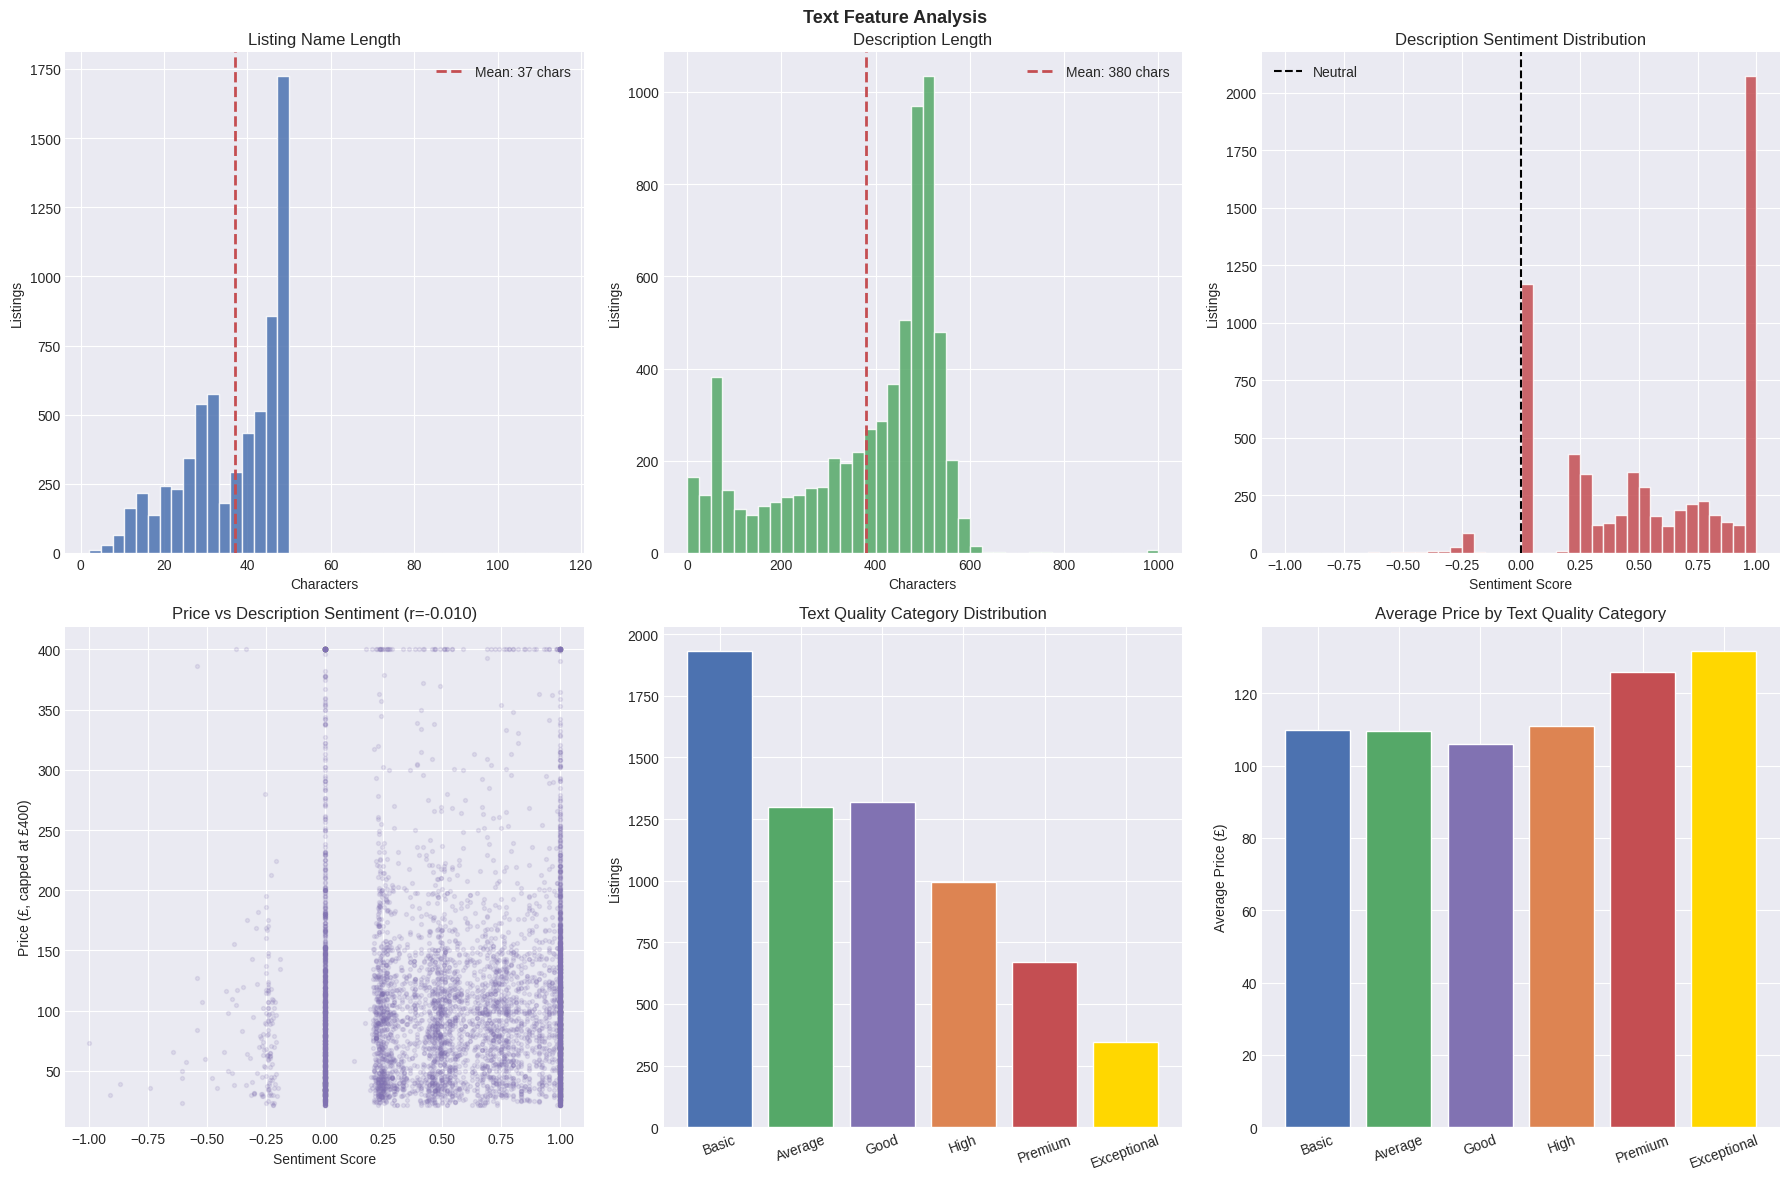

Text Feature Statistics:
       name_length  name_word_count  desc_length  desc_word_count  desc_sentiment_score  overall_text_quality
count     6562.000         6562.000     6562.000         6562.000              6562.000              6562.000
mean        36.991            6.142      380.099           61.413                 0.560                15.012
std         11.854            2.290      165.219           26.892                 0.397                 4.003
min          2.000            1.000        0.000            0.000                -1.000                 3.000
25%         29.000            4.000      284.000           46.000                 0.238                12.250
50%         40.000            6.000      450.000           71.000                 0.580                15.007
75%         48.000            8.000      503.000           81.000                 1.000                17.805
max        115.000           20.000     1000.000          182.000                 1.000        

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Name length distribution
axes[0, 0].hist(df_eda['name_length'], bins=40, color='#4C72B0',
                edgecolor='white', alpha=0.85)
axes[0, 0].axvline(df_eda['name_length'].mean(), color='#C44E52',
                    linewidth=2, linestyle='--',
                    label=f'Mean: {df_eda["name_length"].mean():.0f} chars')
axes[0, 0].set_xlabel('Characters')
axes[0, 0].set_ylabel('Listings')
axes[0, 0].set_title('Listing Name Length')
axes[0, 0].legend()

# Description length
axes[0, 1].hist(df_eda['desc_length'], bins=40, color='#55A868',
                edgecolor='white', alpha=0.85)
axes[0, 1].axvline(df_eda['desc_length'].mean(), color='#C44E52',
                    linewidth=2, linestyle='--',
                    label=f'Mean: {df_eda["desc_length"].mean():.0f} chars')
axes[0, 1].set_xlabel('Characters')
axes[0, 1].set_ylabel('Listings')
axes[0, 1].set_title('Description Length')
axes[0, 1].legend()

# Sentiment distribution
axes[0, 2].hist(df_eda['desc_sentiment_score'], bins=40, color='#C44E52',
                edgecolor='white', alpha=0.85)
axes[0, 2].axvline(0, color='black', linewidth=1.5, linestyle='--', label='Neutral')
axes[0, 2].set_xlabel('Sentiment Score')
axes[0, 2].set_ylabel('Listings')
axes[0, 2].set_title('Description Sentiment Distribution')
axes[0, 2].legend()

# Price vs description sentiment
axes[1, 0].scatter(df_eda['desc_sentiment_score'],
                   np.clip(df_eda['price'], 0, 400),
                   alpha=0.15, s=8, color='#8172B2')
r_sent, _ = pearsonr(df_eda['desc_sentiment_score'], df_eda['price'])
axes[1, 0].set_xlabel('Sentiment Score')
axes[1, 0].set_ylabel('Price (£, capped at £400)')
axes[1, 0].set_title(f'Price vs Description Sentiment (r={r_sent:.3f})')

# Text quality category distribution
tq_cols   = [c for c in df_eda.columns if c.startswith('text_quality_category_')]
tq_labels = [c.replace('text_quality_category_', '') for c in tq_cols]
tq_counts = df_eda[tq_cols].sum()
tq_counts.index = tq_labels
order = ['Basic', 'Average', 'Good', 'High', 'Premium', 'Exceptional']
tq_ordered = tq_counts.reindex([l for l in order if l in tq_counts.index])
colors_tq  = ['#4C72B0', '#55A868', '#8172B2', '#DD8452', '#C44E52', '#FFD700']
axes[1, 1].bar(tq_ordered.index, tq_ordered.values,
               color=colors_tq[:len(tq_ordered)], edgecolor='white')
axes[1, 1].set_ylabel('Listings')
axes[1, 1].set_title('Text Quality Category Distribution')
axes[1, 1].tick_params(axis='x', rotation=20)

# Average price by text quality category
avg_price_tq = {}
for col, label in zip(tq_cols, tq_labels):
    avg_price_tq[label] = df_eda[df_eda[col] == 1]['price'].mean()
tq_price_ordered = {k: avg_price_tq.get(k, 0)
                    for k in order if k in avg_price_tq}
axes[1, 2].bar(tq_price_ordered.keys(), tq_price_ordered.values(),
               color=colors_tq[:len(tq_price_ordered)], edgecolor='white')
axes[1, 2].set_ylabel('Average Price (£)')
axes[1, 2].set_title('Average Price by Text Quality Category')
axes[1, 2].tick_params(axis='x', rotation=20)

plt.suptitle('Text Feature Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_text_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("Text Feature Statistics:")
text_stats_cols = ['name_length', 'name_word_count', 'desc_length',
                   'desc_word_count', 'desc_sentiment_score', 'overall_text_quality']
print(df_eda[text_stats_cols].describe().to_string())


=== Deep Learning Feature Analysis ===
  DistilBERT name embeddings: 32 PCA components
  DistilBERT desc embeddings: 32 PCA components
  ResNet50 image features:    32 PCA components
  Image coverage:             93.5%


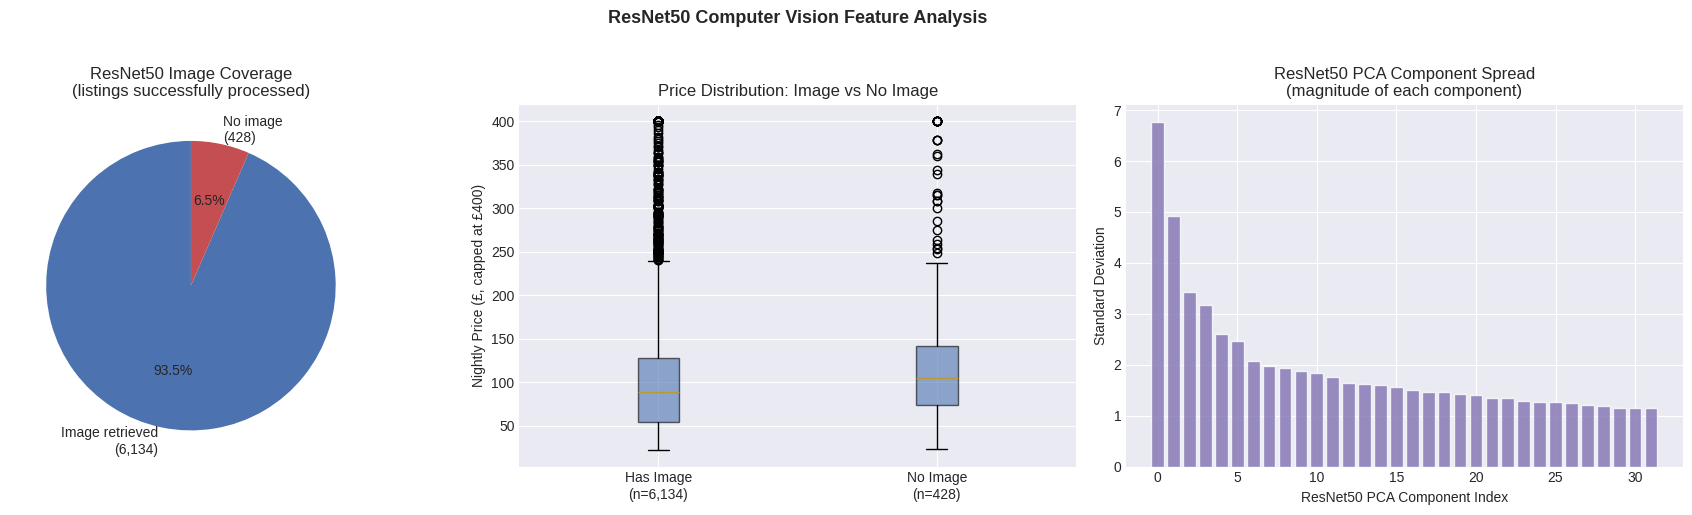

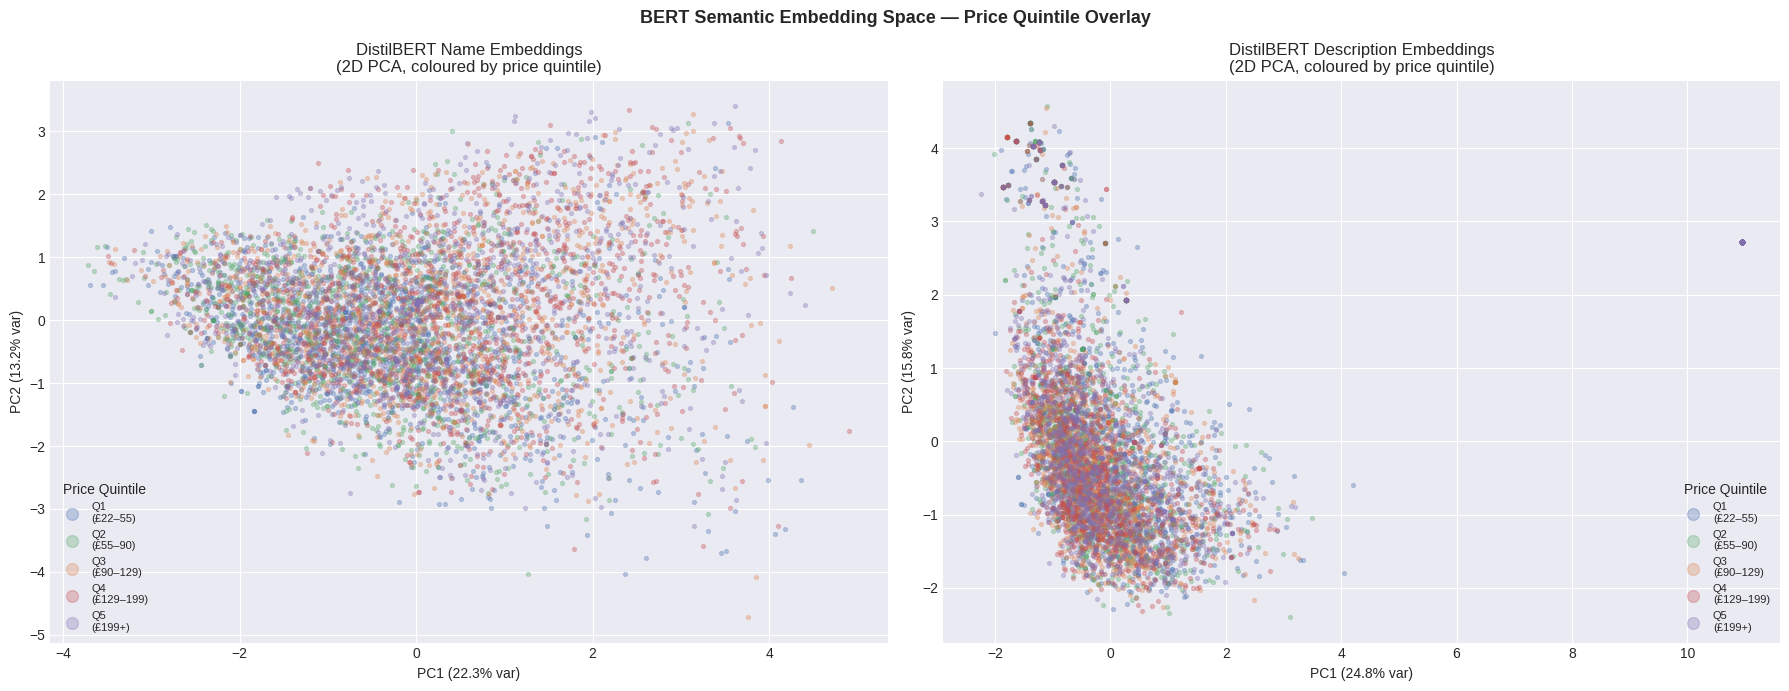

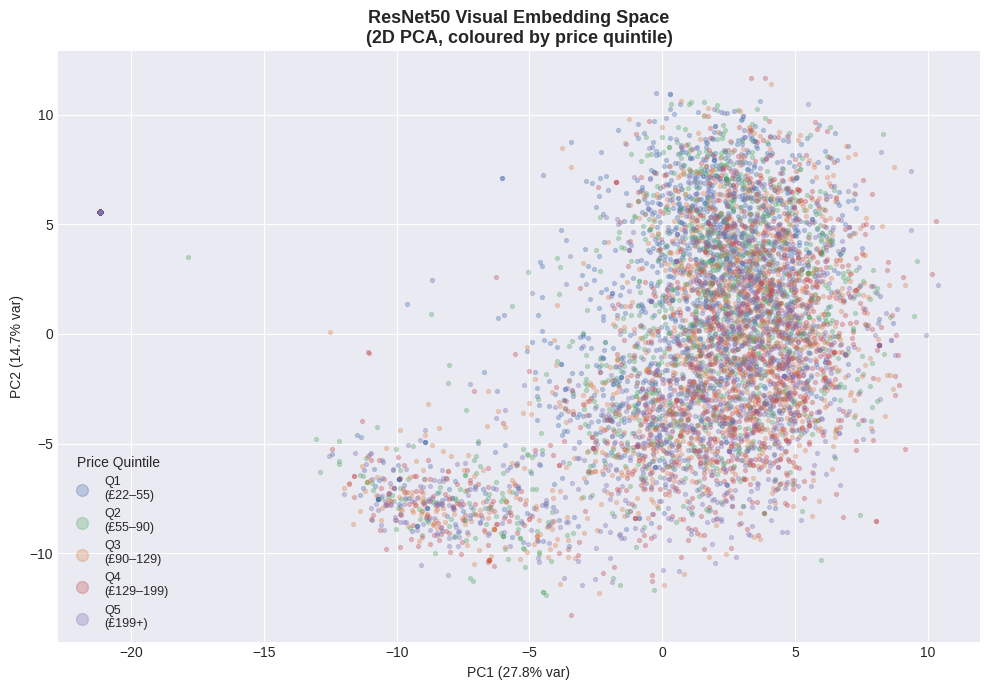


Variance explained by 2D PCA projections:
  Name-BERT:   35.5%
  Desc-BERT:   40.6%
  ResNet50:    42.5%

Note: Absence of strong price-quintile clustering in embedding space
is consistent with the ablation study finding that structured features
dominate price prediction over semantic/visual signals.


In [12]:
print("=== Deep Learning Feature Analysis ===")
print(f"  DistilBERT name embeddings: {len(bert_name)} PCA components")
print(f"  DistilBERT desc embeddings: {len(bert_desc)} PCA components")
print(f"  ResNet50 image features:    {len(resnet)} PCA components")
print(f"  Image coverage:             {df_eda['has_picture'].mean()*100:.1f}%")

# --- 11a. Image Coverage ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

has_img_counts = df_eda['has_picture'].value_counts()
axes[0].pie([has_img_counts.get(1, 0), has_img_counts.get(0, 0)],
            labels=[f'Image retrieved\n({has_img_counts.get(1,0):,})',
                    f'No image\n({has_img_counts.get(0,0):,})'],
            autopct='%1.1f%%', colors=['#4C72B0', '#C44E52'],
            startangle=90)
axes[0].set_title('ResNet50 Image Coverage\n(listings successfully processed)')

# Price with vs without image
price_with    = df_eda[df_eda['has_picture'] == 1]['price']
price_without = df_eda[df_eda['has_picture'] == 0]['price']
axes[1].boxplot([price_with.clip(upper=400).values,
                 price_without.clip(upper=400).values],
                labels=[f'Has Image\n(n={len(price_with):,})',
                        f'No Image\n(n={len(price_without):,})'],
                patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.6))
axes[1].set_ylabel('Nightly Price (£, capped at £400)')
axes[1].set_title('Price Distribution: Image vs No Image')

# ResNet PCA variance distribution (component magnitudes as proxy for variance)
resnet_data  = df_eda[resnet].values
resnet_stds  = df_eda[resnet].std().sort_values(ascending=False)
axes[2].bar(range(len(resnet_stds)), resnet_stds.values,
            color='#8172B2', edgecolor='white', alpha=0.8)
axes[2].set_xlabel('ResNet50 PCA Component Index')
axes[2].set_ylabel('Standard Deviation')
axes[2].set_title('ResNet50 PCA Component Spread\n(magnitude of each component)')

plt.suptitle('ResNet50 Computer Vision Feature Analysis',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_resnet.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 11b. BERT Embedding Space (PCA Visualisation) ---
# Apply 2D PCA to the 32 name-BERT and 32 desc-BERT components
# to visualise whether semantic content clusters by price tier

price_quintiles = pd.qcut(df_eda['price'], q=5,
                           labels=['Q1\n(£22–55)', 'Q2\n(£55–90)',
                                   'Q3\n(£90–129)', 'Q4\n(£129–199)',
                                   'Q5\n(£199+)'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Name-BERT 2D projection
name_bert_data = df_eda[bert_name].values
pca_name = PCA(n_components=2, random_state=42)
name_2d  = pca_name.fit_transform(name_bert_data)

palette = ['#4C72B0', '#55A868', '#DD8452', '#C44E52', '#8172B2']
for idx, (q_label, color) in enumerate(zip(price_quintiles.cat.categories, palette)):
    mask = price_quintiles == q_label
    axes[0].scatter(name_2d[mask, 0], name_2d[mask, 1],
                    c=color, alpha=0.3, s=8, label=q_label)

axes[0].set_xlabel(f'PC1 ({pca_name.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca_name.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].set_title('DistilBERT Name Embeddings\n(2D PCA, coloured by price quintile)')
axes[0].legend(title='Price Quintile', fontsize=8, markerscale=3)

# Description-BERT 2D projection
desc_bert_data = df_eda[bert_desc].values
pca_desc = PCA(n_components=2, random_state=42)
desc_2d  = pca_desc.fit_transform(desc_bert_data)

for q_label, color in zip(price_quintiles.cat.categories, palette):
    mask = price_quintiles == q_label
    axes[1].scatter(desc_2d[mask, 0], desc_2d[mask, 1],
                    c=color, alpha=0.3, s=8, label=q_label)

axes[1].set_xlabel(f'PC1 ({pca_desc.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca_desc.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].set_title('DistilBERT Description Embeddings\n(2D PCA, coloured by price quintile)')
axes[1].legend(title='Price Quintile', fontsize=8, markerscale=3)

plt.suptitle('BERT Semantic Embedding Space — Price Quintile Overlay',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_bert_pca.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 11c. ResNet50 Embedding Space ---
fig, ax = plt.subplots(figsize=(10, 7))

resnet_data = df_eda[resnet].values
pca_img = PCA(n_components=2, random_state=42)
img_2d  = pca_img.fit_transform(resnet_data)

for q_label, color in zip(price_quintiles.cat.categories, palette):
    mask = price_quintiles == q_label
    ax.scatter(img_2d[mask, 0], img_2d[mask, 1],
               c=color, alpha=0.3, s=8, label=q_label)

ax.set_xlabel(f'PC1 ({pca_img.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca_img.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('ResNet50 Visual Embedding Space\n(2D PCA, coloured by price quintile)',
             fontsize=13, fontweight='bold')
ax.legend(title='Price Quintile', fontsize=9, markerscale=3)
plt.tight_layout()
plt.savefig('eda_resnet_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVariance explained by 2D PCA projections:")
print(f"  Name-BERT:   {pca_name.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  Desc-BERT:   {pca_desc.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  ResNet50:    {pca_img.explained_variance_ratio_.sum()*100:.1f}%")
print("\nNote: Absence of strong price-quintile clustering in embedding space")
print("is consistent with the ablation study finding that structured features")
print("dominate price prediction over semantic/visual signals.")


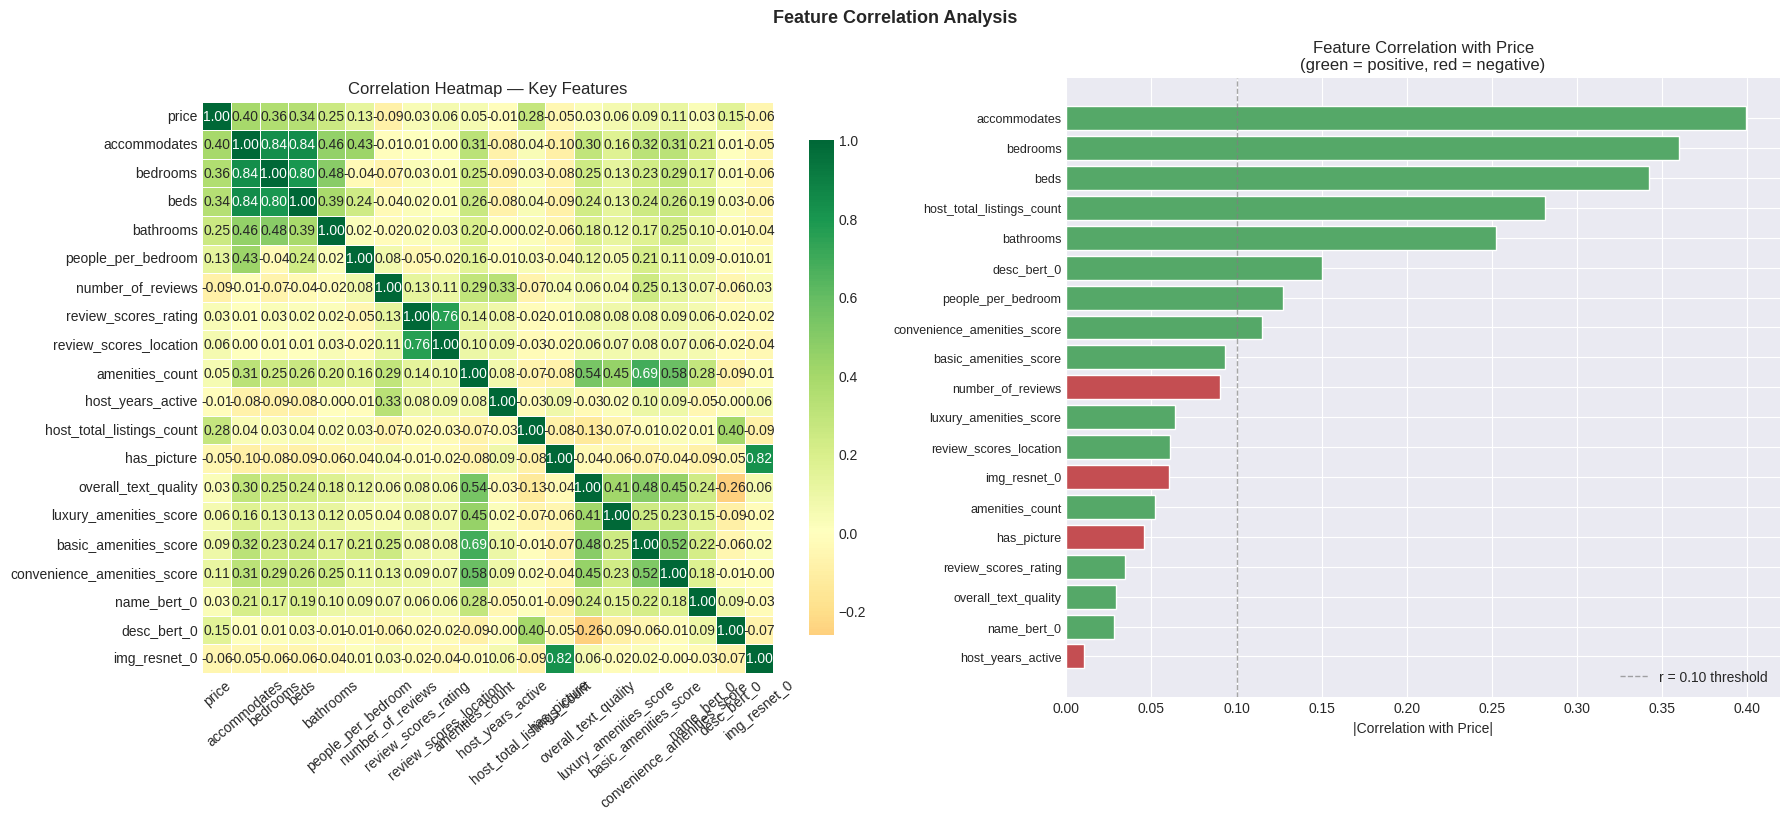

Top 10 features correlated with price:
  +0.399  accommodates
  +0.360  bedrooms
  +0.342  beds
  +0.281  host_total_listings_count
  +0.252  bathrooms
  +0.150  desc_bert_0
  +0.127  people_per_bedroom
  +0.115  convenience_amenities_score
  +0.093  basic_amenities_score
  -0.090  number_of_reviews


In [13]:
# Select key numeric and binary features for correlation analysis
corr_features = [
    'price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'people_per_bedroom', 'number_of_reviews', 'review_scores_rating',
    'review_scores_location', 'amenities_count', 'host_years_active',
    'host_total_listings_count', 'has_picture', 'overall_text_quality',
    'luxury_amenities_score', 'basic_amenities_score', 'convenience_amenities_score',
    'name_bert_0', 'desc_bert_0', 'img_resnet_0'
]
corr_features = [c for c in corr_features if c in df_eda.columns]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Correlation heatmap
corr_matrix = df_eda[corr_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, ax=axes[0], cbar_kws={'shrink': 0.8},
            linewidths=0.5, linecolor='white')
axes[0].set_title('Correlation Heatmap — Key Features')
axes[0].tick_params(axis='x', rotation=40)
axes[0].tick_params(axis='y', rotation=0)

# Top correlations with price (absolute)
price_corr = corr_matrix['price'].drop('price').abs().sort_values(ascending=True)
colors_corr = ['#C44E52' if corr_matrix['price'][f] < 0 else '#55A868'
               for f in price_corr.index]
axes[1].barh(range(len(price_corr)), price_corr.values,
             color=colors_corr, edgecolor='white')
axes[1].set_yticks(range(len(price_corr)))
axes[1].set_yticklabels(price_corr.index, fontsize=9)
axes[1].set_xlabel('|Correlation with Price|')
axes[1].set_title('Feature Correlation with Price\n(green = positive, red = negative)')
axes[1].axvline(0.1, color='gray', linestyle='--', linewidth=1, alpha=0.7,
                label='r = 0.10 threshold')
axes[1].legend()

plt.suptitle('Feature Correlation Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 features correlated with price:")
full_corr = df_eda[corr_features].corr()['price'].drop('price').abs().sort_values(
    ascending=False)
for feat, val in full_corr.head(10).items():
    direction = '+' if df_eda[corr_features].corr()['price'][feat] > 0 else '-'
    print(f"  {direction}{val:.3f}  {feat}")

Market Segment Statistics:
                    price                 review_scores_rating amenities_count accommodates host_is_superhost
                    count    mean  median                 mean            mean         mean          <lambda>
price_segment                                                                                                
Budget\n(<£55)       1663  38.820  38.000                4.680          26.840        1.840            28.140
Mid-Range\n(£55–90)  1664  73.500  73.000                4.690          31.530        3.330            25.780
Premium\n(£90–129)   1618 108.150 107.000                4.720          36.830        4.720            28.060
Luxury\n(£129+)      1617 230.750 169.000                4.720          35.760        5.780            30.430


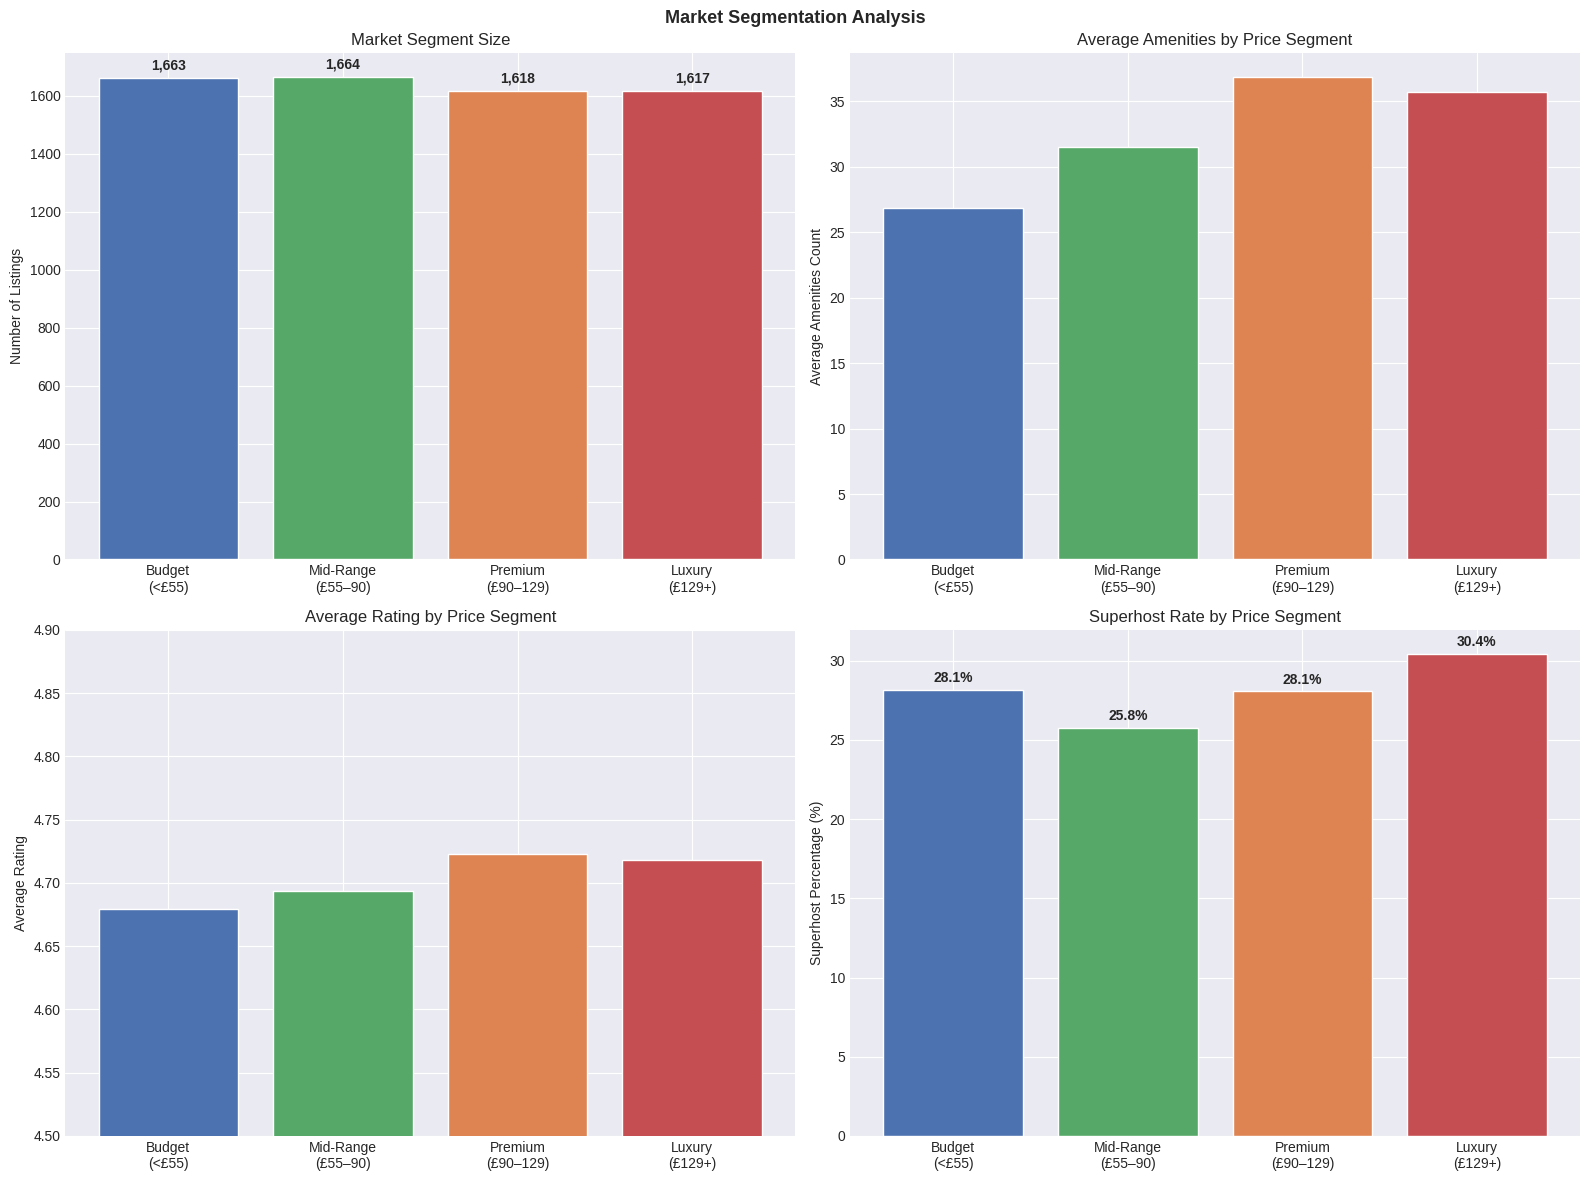

In [14]:
df_eda['price_segment'] = pd.cut(
    df_eda['price'],
    bins=[0, 55, 90, 129, 1013],
    labels=['Budget\n(<£55)', 'Mid-Range\n(£55–90)',
            'Premium\n(£90–129)', 'Luxury\n(£129+)']
)

seg_stats = df_eda.groupby('price_segment', observed=True).agg({
    'price':                ('count', 'mean', 'median'),
    'review_scores_rating': 'mean',
    'amenities_count':      'mean',
    'accommodates':         'mean',
    'host_is_superhost':    lambda x: (x == 1).mean() * 100
}).round(2)

print("Market Segment Statistics:")
print(seg_stats.to_string())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
seg_labels  = df_eda['price_segment'].cat.categories
seg_counts  = df_eda['price_segment'].value_counts(sort=False)
seg_colours = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']

# Segment size
axes[0, 0].bar(seg_labels, seg_counts.values, color=seg_colours, edgecolor='white')
axes[0, 0].set_ylabel('Number of Listings')
axes[0, 0].set_title('Market Segment Size')
for i, v in enumerate(seg_counts.values):
    axes[0, 0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

# Average amenities by segment
seg_amenities = df_eda.groupby('price_segment', observed=True)['amenities_count'].mean()
axes[0, 1].bar(seg_labels, seg_amenities.values, color=seg_colours, edgecolor='white')
axes[0, 1].set_ylabel('Average Amenities Count')
axes[0, 1].set_title('Average Amenities by Price Segment')

# Average rating by segment
seg_rating = df_eda.groupby('price_segment', observed=True)['review_scores_rating'].mean()
axes[1, 0].bar(seg_labels, seg_rating.values, color=seg_colours, edgecolor='white')
axes[1, 0].set_ylabel('Average Rating')
axes[1, 0].set_title('Average Rating by Price Segment')
axes[1, 0].set_ylim([4.5, 4.9])

# Superhost % by segment
seg_superhost = df_eda.groupby('price_segment', observed=True)['host_is_superhost'].apply(
    lambda x: (x == 1).mean() * 100
)
axes[1, 1].bar(seg_labels, seg_superhost.values, color=seg_colours, edgecolor='white')
axes[1, 1].set_ylabel('Superhost Percentage (%)')
axes[1, 1].set_title('Superhost Rate by Price Segment')
for i, v in enumerate(seg_superhost.values):
    axes[1, 1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Market Segmentation Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_market_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
print("=" * 65)
print("KEY FINDINGS — Manchester Airbnb EDA")
print("=" * 65)

print("\n1. DATASET")
print(f"   Listings analysed:         {len(df_eda):,}")
print(f"   Features (post-process):   {df_eda.shape[1]:,}")
print(f"   Deep learning features:    {len(bert_name)+len(bert_desc)+len(resnet)+1}")

print("\n2. PRICE DISTRIBUTION")
print(f"   Mean:    £{df_eda['price'].mean():.2f}")
print(f"   Median:  £{df_eda['price'].median():.2f}")
print(f"   Std:     £{df_eda['price'].std():.2f}")
print(f"   Skew:    {df_eda['price'].skew():.2f} (right-skewed, log-normal shape)")

print("\n3. ACCOMMODATION")
print(f"   Mean accommodates: {df_eda['accommodates'].mean():.1f} guests")
print(f"   Mean bedrooms:     {df_eda['bedrooms'].mean():.1f}")
print(f"   Strongest predictor: accommodates (r = "
      f"{df_eda[['price','accommodates']].corr().iloc[0,1]:.3f})")

print("\n4. ROOM TYPES")
for col in room_cols:
    label = col.replace('room_type_', '')
    n = df_eda[col].sum()
    avg = df_eda[df_eda[col]==1]['price'].mean()
    print(f"   {label:<22}: {n:>5,} listings  avg £{avg:.0f}")

print("\n5. HOST")
superhost_pct = df_eda['host_is_superhost'].mean() * 100
print(f"   Superhost rate:    {superhost_pct:.1f}%")
print(f"   Overall premium:   {premium_overall:.1f}% (marginal; confounded by")
print(f"                      room-type composition — see Cell 7)")
print(f"   Median host tenure: {df_eda['host_years_active'].median():.1f} years")

print("\n6. REVIEWS")
print(f"   Mean overall rating:   {df_eda['review_scores_rating'].mean():.3f}/5.0")
print(f"   Highest dimension:     "
      f"{df_eda[review_cols].mean().idxmax().replace('review_scores_','').title()}")
print(f"   Lowest dimension:      "
      f"{df_eda[review_cols].mean().idxmin().replace('review_scores_','').title()}")

print("\n7. AMENITIES")
print(f"   Mean amenity count:  {df_eda['amenities_count'].mean():.0f}")
top3 = amenity_prevalence.head(3)
for feat, count in top3.items():
    print(f"   Most common: {feat.replace('has_','').replace('_',' ').title()} "
          f"({count/len(df_eda)*100:.0f}% of listings)")

print("\n8. TEXT & NLP")
print(f"   Mean description length:  {df_eda['desc_length'].mean():.0f} characters")
print(f"   Mean sentiment score:     {df_eda['desc_sentiment_score'].mean():.3f}")
print(f"   Price-sentiment corr:     r = {r_sent:.3f} (weak signal)")

print("\n9. DEEP LEARNING FEATURES")
print(f"   Image coverage (ResNet50): {df_eda['has_picture'].mean()*100:.1f}%")
print(f"   BERT name PCA 2D variance: {pca_name.explained_variance_ratio_.sum()*100:.1f}%")
print(f"   BERT desc PCA 2D variance: {pca_desc.explained_variance_ratio_.sum()*100:.1f}%")
print(f"   ResNet PCA 2D variance:    {pca_img.explained_variance_ratio_.sum()*100:.1f}%")
print(f"   Embedding clusters: No strong price-quintile separation")
print(f"   observed — consistent with ablation results showing structured")
print(f"   features dominate prediction.")

print("\n10. NOTE ON EXCLUDED FEATURE")
print(f"    price_per_person was excluded from all analysis and modelling.")
print(f"    It is derived directly from the target variable (price / accommodates)")
print(f"    and constitutes data leakage.")
print("=" * 65)


KEY FINDINGS — Manchester Airbnb EDA

1. DATASET
   Listings analysed:         6,562
   Features (post-process):   293
   Deep learning features:    97

2. PRICE DISTRIBUTION
   Mean:    £112.00
   Median:  £90.00
   Std:     £112.32
   Skew:    4.86 (right-skewed, log-normal shape)

3. ACCOMMODATION
   Mean accommodates: 3.9 guests
   Mean bedrooms:     1.7
   Strongest predictor: accommodates (r = 0.399)

4. ROOM TYPES
   Entire home/apt       : 4,438 listings  avg £138
   Hotel room            :    13 listings  avg £60
   Private room          : 2,075 listings  avg £58
   Shared room           :    36 listings  avg £53

5. HOST
   Superhost rate:    28.1%
   Overall premium:   -1.8% (marginal; confounded by
                      room-type composition — see Cell 7)
   Median host tenure: 5.3 years

6. REVIEWS
   Mean overall rating:   4.703/5.0
   Highest dimension:     Communication
   Lowest dimension:      Value

7. AMENITIES
   Mean amenity count:  33
   Most common: Wifi (96% of